# Simple Chatbot
- Workflow
    - START -> Chatbot -> END
- State
    - Full users conversations i.e. question and responses both must be stored

In [11]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage

# Defining the state
- The type of messages that we will be adding is AIMessage, HumanMessage, Sysystem message which are all derived from BaseMessage thus list[BaseMessage] is used
- As we will need to append messages in the messages state attribute instead of using operator.add more optimized way of adding LLM based messages (AIMessage, HumanMessage, SystemMessage) is add_message which is inbuilt in langgraph
- 

In [12]:
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage

class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

# Defining the function

In [13]:
def chat_bot(state: State):
    model = ChatGroq(model = "qwen/qwen3-32b")

    response = model.invoke(state["messages"])
    
    return {"messages": [response]}
    

In [14]:
# Defining graph
graph = StateGraph(State)

# Adding Nodes
graph.add_node("chat_bot", chat_bot)

# Adding edges
graph.add_edge(START, "chat_bot")
graph.add_edge("chat_bot", END)


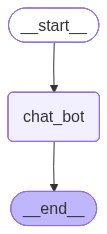

In [15]:
# Building the workflow
workflow = graph.compile()
workflow


In [16]:
initial_state = {
    "messages": [HumanMessage(content= "What is the capital of India?")]
}
workflow.invoke(initial_state)


{'messages': [HumanMessage(content='What is the capital of India?', additional_kwargs={}, response_metadata={}, id='ae54b11b-c8aa-4ad4-b10c-e43e3cdb9d42'),
  AIMessage(content='<think>\nOkay, so the user is asking, "What is the capital of India?" Let me think about how to approach this.\n\nFirst, I need to recall the correct answer. I remember that New Delhi is the capital of India. But wait, sometimes people confuse it with Delhi. Let me double-check. Yes, the capital is New Delhi, which is a part of the National Capital Territory of Delhi.\n\nI should also consider if there\'s any historical context. Before 1911, the capital was Calcutta (now Kolkata), but then it was moved to Delhi to shift the center of power towards the north. The construction of New Delhi started in the 1920s and it became the capital after India\'s independence in 1947. That\'s probably useful background information.\n\nThe user might not know the difference between Delhi and New Delhi. So explaining that New De

- Now the basic structure of question and answer is done
- Now we need to enable continuous chatting and responses to flow in until the user manually stops it. For which a loop must run

In [19]:
while True:
    user_message = input("Type here")
    if user_message.strip().lower() in ["exit", "quit", "end", "bye"]:
        break
    else:
       response = workflow.invoke({"messages": HumanMessage(content=user_message)})
       print(f"User: {user_message}")
       print(f"Response: {response}")

User: Hi
Response: {'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='6d397e9f-5efa-4e3d-ac5b-41db4feacbdc'), AIMessage(content='<think>\nOkay, the user just sent "Hi". That\'s pretty open-ended. I need to respond in a friendly and helpful way. Let me start by greeting them back and asking how I can assist. Maybe something like, "Hello! How can I assist you today?" That should encourage them to elaborate on what they need help with. I should keep it simple and welcoming.\n</think>\n\nHello! How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 89, 'prompt_tokens': 9, 'total_tokens': 98, 'completion_time': 0.170851939, 'completion_tokens_details': None, 'prompt_time': 0.000447902, 'prompt_tokens_details': None, 'queue_time': 0.045985346, 'total_time': 0.171299841}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprob

- When user types question1 and gets answer1 the workflow end, because the workflow is built such that it takes the question answers it and then ENDs it. So when user asks next question the state is reset as its starting the workflow again
- Here it does not have context of previous values, i.e. memory is missing
- When the workflow ends the state is no more stored in memory
- To store the state we can either store it in the database or in memory (RAM). This is where the concept of persistant memory comes into play



# Adding memory to the chatbot

# Define a checkpointer
- MemorySaver() is a simple in-memory checkpointer
- It stores checkpoints in RAM while the program is running.


In [21]:

from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

In [ ]:

# Defining the graoh
graph = StateGraph(State)

# Adding Nodes
graph.add_node("chat_bot", chat_bot)

# Adding edges
graph.add_edge(START, "chat_bot")
graph.add_edge("chat_bot", END)


In [ ]:
# Worklfow creation
workflow = graph.compile(checkpointer =  checkpointer)


- Here we are saying the workflow to persists the state state across runs
- If the history of messages have to be maintained then threads must be used.
- For an individual a thread is created
- This has to be passed while invoking the graph

In [ ]:
thread_id = "1"

while True:
    user_message = input("Type here")
    if user_message.strip().lower() in ["exit", "quit", "end", "bye"]:
        break
    else:
        # Passing the thread details
        config = {
            "configurable":{
                "thread_id": thread_id
            }
        }
        response = workflow.invoke(
            {"messages": HumanMessage(content=user_message)}, 
            config = config
        )
        print(f"User: {user_message}")
        print(f"Response: {response}")

User: Hi
Response: {'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='25479da2-2d0a-4048-93e1-7b7d7f48c2ac'), AIMessage(content='<think>\nOkay, the user said "Hi". That\'s pretty casual. I should respond in a friendly and welcoming way. Maybe ask how I can assist them today. Keep it open-ended so they feel comfortable asking anything. Let me make sure the tone is approachable.\n</think>\n\nHello! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 69, 'prompt_tokens': 9, 'total_tokens': 78, 'completion_time': 0.156251287, 'completion_tokens_details': None, 'prompt_time': 0.000189117, 'prompt_tokens_details': None, 'queue_time': 0.16015304, 'total_time': 0.156440404}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_2bfcc54d36', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cbe3b-7ecc-7333-a7a9-98e4ff85d5eb-0', tool_

- Now its able to retain its memory and have access to the previous questions and responses too
- Working
    - When user asks question1, the LLM responds with response1. Now the workflow ends
    - Now this state will be stored in RAM because checkpointer is enabled
    - When user asks question2, the state will be fetched from the memory and then LLM will have the information about question1, response1 and question2. Thus enabling access to the history and context of message exchanges
    - Its appending the messages because the reducer used is add message

# Printing the intermediate states and the final state
- config must be passed to retrive the state of the particular individual

In [ ]:
workflow.get_state(config = config)

StateSnapshot(values={'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='25479da2-2d0a-4048-93e1-7b7d7f48c2ac'), AIMessage(content='<think>\nOkay, the user said "Hi". That\'s pretty casual. I should respond in a friendly and welcoming way. Maybe ask how I can assist them today. Keep it open-ended so they feel comfortable asking anything. Let me make sure the tone is approachable.\n</think>\n\nHello! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 69, 'prompt_tokens': 9, 'total_tokens': 78, 'completion_time': 0.156251287, 'completion_tokens_details': None, 'prompt_time': 0.000189117, 'prompt_tokens_details': None, 'queue_time': 0.16015304, 'total_time': 0.156440404}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_2bfcc54d36', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cbe3b-7ecc-7333-a7a9-98e4ff85d5eb-0', too

- `get_state()`: Returns the final state
- `get_state_history()`: Returns all the intermediate results of the state
    - The state value for the last value in the list will be empty because thats the 1st initial state where no state was maintained


In [26]:
list(workflow.get_state_history(config=config))

[StateSnapshot(values={'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='25479da2-2d0a-4048-93e1-7b7d7f48c2ac'), AIMessage(content='<think>\nOkay, the user said "Hi". That\'s pretty casual. I should respond in a friendly and welcoming way. Maybe ask how I can assist them today. Keep it open-ended so they feel comfortable asking anything. Let me make sure the tone is approachable.\n</think>\n\nHello! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 69, 'prompt_tokens': 9, 'total_tokens': 78, 'completion_time': 0.156251287, 'completion_tokens_details': None, 'prompt_time': 0.000189117, 'prompt_tokens_details': None, 'queue_time': 0.16015304, 'total_time': 0.156440404}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_2bfcc54d36', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cbe3b-7ecc-7333-a7a9-98e4ff85d5eb-0', to